# MNIST Multi-Class Classification — Training Notebook

This notebook trains a deep neural network on the classic **MNIST handwritten digits dataset** (10 classes, digits `0`–`9`).

**What this notebook does:**
1. Loads MNIST via `tf.keras.datasets`.
2. **Explores the dataset** with interactive Plotly charts — sample grid, class distribution, pixel-intensity histogram, and per-class average digit.
3. Normalizes pixel values to `[0, 1]`.
4. Builds a configurable `Sequential` DNN (Flatten → Dense → Dropout → Dense → Softmax) with a Mermaid architecture diagram.
5. Trains the model and tracks metrics per epoch.
6. **Diagnoses test performance** with multiple views: training curves, confusion matrix, per-class precision/recall/F1, confidence histograms (correct vs wrong), and a gallery of misclassified images.
7. Persists the trained model + helper objects with **`pickle`** so the companion prediction notebook can reuse them.

A single global flag (`MODE`) switches between **`production`** (full training, full epochs) and **`testing`** (fast smoke run on a subset for notebook iteration).

## 1. Environment Setup

Only the packages actually used in this notebook are listed below, with pinned versions for reproducibility.

Python version: `3.12.13`



| Package | Version | Purpose |
|---|---|---|
| `tensorflow` | `2.20.0` | Model building, training, MNIST loader |
| `numpy` | `2.0.2` | Array math |
| `pandas` | `2.2.2` | History dataframe |
| `plotly` | `5.24.1` | Interactive plots (loss/accuracy curves, confusion matrix) |
| `scikit-learn` | `1.6.1` | Confusion matrix utility |

### 1a. Default path — Google Colab

Colab is the intended **first** runtime for this notebook. The cell below installs everything into the active Colab runtime. Just **Run** it once per session and continue. There is nothing else to do.

> Colab kernels run in a managed, ephemeral VM, so a local `venv` is not applicable here — `%pip install` is the right tool.

## 2. Imports

Standard scientific stack plus Plotly for interactive charts and `pickle` for serialization.

In [23]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import plotly
import sklearn
from tensorflow.keras import layers

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.metrics import confusion_matrix, classification_report

np.set_printoptions(linewidth=200)
pd.options.display.float_format = "{:.4f}".format

print("TensorFlow:", tf.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Plotly:", plotly.__version__)
print("Scikit-Learn:", sklearn.__version__)

TensorFlow: 2.20.0
Numpy: 2.0.2
Pandas: 2.2.2
Plotly: 5.24.1
Scikit-Learn: 1.6.1


In [24]:
# !pip list -> human readable
# !pip freeze -> machine readable



## 3. Global Configuration

The `MODE` flag controls the whole notebook:

- **`"production"`** — full dataset, full epochs, saves artifacts that the prediction notebook will load.
- **`"testing"`** — small subset, very few epochs. Useful when iterating on the notebook itself so you don't wait minutes for each run.

All downstream cells branch on `IS_PRODUCTION` so the rest of the code stays identical.

In [25]:
MODE = "production"  # "production" | "testing"

assert MODE in {"production", "testing"}, f"Unknown MODE: {MODE!r}"
IS_PRODUCTION = MODE == "production"

CONFIG = {
    "learning_rate": 0.003,
    "epochs": 50 if IS_PRODUCTION else 3,
    "batch_size": 4000 if IS_PRODUCTION else 512,
    "validation_split": 0.2,
    "train_subset": None if IS_PRODUCTION else 5_000,
    "test_subset":  None if IS_PRODUCTION else 1_000,
    "hidden_units_1": 256,
    "hidden_units_2": 128,
    "dropout_rate": 0.2,
    "random_seed": 42,
}

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

tf.keras.utils.set_random_seed(CONFIG["random_seed"])

print(f"Running in {MODE.upper()} mode")
print(f"Config: {CONFIG}")

Running in PRODUCTION mode
Config: {'learning_rate': 0.003, 'epochs': 50, 'batch_size': 4000, 'validation_split': 0.2, 'train_subset': None, 'test_subset': None, 'hidden_units_1': 256, 'hidden_units_2': 128, 'dropout_rate': 0.2, 'random_seed': 42}


## 4. Load the Dataset

`tf.keras.datasets.mnist.load_data()` returns:
- `x_train`, `x_test`: `uint8` arrays of shape `(N, 28, 28)` — pixel values `0`–`255`.
- `y_train`, `y_test`: integer labels `0`–`9`.

In `testing` mode we slice the arrays to keep the notebook responsive.

In [26]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

if not IS_PRODUCTION:
    x_train = x_train[: CONFIG["train_subset"]]
    y_train = y_train[: CONFIG["train_subset"]]
    x_test  = x_test[:  CONFIG["test_subset"]]
    y_test  = y_test[:  CONFIG["test_subset"]]

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")

x_train: (60000, 28, 28), y_train: (60000,)
x_test : (10000, 28, 28),  y_test : (10000,)


## 5. Explore a Few Samples

Quick sanity check with an interactive Plotly grid of 10 random training images.

In [27]:
rng = np.random.default_rng(CONFIG["random_seed"])
sample_idx = rng.choice(len(x_train), size=10, replace=False)

fig = make_subplots(rows=2, cols=5,
                    subplot_titles=[f"label = {y_train[i]}" for i in sample_idx])
for plot_idx, img_idx in enumerate(sample_idx):
    r, c = plot_idx // 5 + 1, plot_idx % 5 + 1
    fig.add_trace(
        go.Heatmap(z=x_train[img_idx][::-1], colorscale="gray_r", showscale=False),
        row=r, col=c,
    )
fig.update_layout(
    title="Random MNIST training samples",
    height=420, width=900,
    margin=dict(l=20, r=20, t=60, b=20),
)
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False, scaleanchor="x")
fig.show()

## 5b. Class distribution — train vs test

Before training anything, check whether the **labels are balanced**. A skewed class distribution would force us to either re-weight the loss or up-/down-sample — MNIST is fortunately close to uniform, but it's still good practice to verify.

In [28]:
train_counts = np.bincount(y_train, minlength=10)
test_counts  = np.bincount(y_test,  minlength=10)
digits = [str(i) for i in range(10)]

fig_dist = go.Figure()
fig_dist.add_trace(go.Bar(
    x=digits, y=train_counts, name="train",
    text=train_counts, textposition="outside", marker_color="#1d4ed8",
))
fig_dist.add_trace(go.Bar(
    x=digits, y=test_counts, name="test",
    text=test_counts, textposition="outside", marker_color="#15803d",
))
fig_dist.update_layout(
    title="Class distribution — number of examples per digit",
    xaxis_title="digit",
    yaxis_title="count",
    barmode="group",
    height=420, width=900,
    legend=dict(orientation="h", y=-0.2),
)
fig_dist.show()

ratio = train_counts.max() / train_counts.min()
print(f"Train: total={train_counts.sum():>6d}  min={train_counts.min()}  max={train_counts.max()}  max/min ratio={ratio:.2f}")
print(f"Test : total={test_counts.sum():>6d}  min={test_counts.min()}  max={test_counts.max()}")

Train: total= 60000  min=5421  max=6742  max/min ratio=1.24
Test : total= 10000  min=892  max=1135


## 5c. Pixel-intensity distribution

A histogram of raw pixel values across a sample of training images. MNIST is mostly background (a huge spike at `0`) with a thin tail toward `255` for the ink. This is exactly the distribution we want to rescale to `[0, 1]` before feeding it to the network — which is what §6 will do next.

In [29]:
n_for_hist = min(2000, len(x_train))
pixel_sample = x_train[:n_for_hist].ravel()

fig_pix = px.histogram(
    pixel_sample, nbins=64,
    labels={"value": "pixel intensity (0-255)"},
    title=f"Raw pixel-intensity distribution (sample of {n_for_hist} training images)",
    color_discrete_sequence=["#3730a3"],
)
fig_pix.update_layout(
    yaxis_type="log",
    yaxis_title="count (log scale)",
    showlegend=False,
    height=380, width=900,
    bargap=0.02,
)
fig_pix.show()

print(f"min={pixel_sample.min()}  max={pixel_sample.max()}  "
      f"mean={pixel_sample.mean():.1f}  median={np.median(pixel_sample):.0f}")

Output hidden; open in https://colab.research.google.com to view.

## 5d. Average digit per class

The pixel-wise average of every training image belonging to each class. The "ghost" digits that emerge tell you what the model essentially has to learn to distinguish — and they immediately explain why pairs like `4` ↔ `9` or `3` ↔ `5` are the most common mistakes a small DNN makes on MNIST.

In [30]:
mean_images = np.stack([
    x_train[y_train == d].mean(axis=0) for d in range(10)
])

fig_mean = make_subplots(
    rows=2, cols=5,
    subplot_titles=[f"mean of '{d}'  (n={(y_train == d).sum()})" for d in range(10)],
    vertical_spacing=0.12,
)
for d in range(10):
    r, c = d // 5 + 1, d % 5 + 1
    fig_mean.add_trace(
        go.Heatmap(z=mean_images[d][::-1], colorscale="gray_r", showscale=False),
        row=r, col=c,
    )
fig_mean.update_xaxes(visible=False)
fig_mean.update_yaxes(visible=False, scaleanchor="x")
fig_mean.update_layout(
    title="Average digit per class (pixel-wise mean over the training set)",
    height=440, width=950,
    margin=dict(l=20, r=20, t=80, b=20),
)
fig_mean.show()

## 6. Normalize Features

Scale pixel intensities from `[0, 255]` (uint8) to `[0, 1]` (float32). Neural nets train faster and more stably on small, zero-centered inputs.

In [31]:
def normalize(images: np.ndarray) -> np.ndarray:
    return images.astype("float32") / 255.0

x_train_norm = normalize(x_train)
x_test_norm  = normalize(x_test)

print(f"x_train_norm range: [{x_train_norm.min():.3f}, {x_train_norm.max():.3f}]")

x_train_norm range: [0.000, 1.000]


## 7. Build the Model

A small but effective topology that reliably exceeds **98% test accuracy** on MNIST.

### Architecture diagram

The next cell renders a Mermaid `flowchart` via `mermaid.ink` (a public SVG-rendering service). This works in **Google Colab, Jupyter, JupyterLab, and VS Code** — anywhere `IPython.display` is supported — because the diagram is fetched as a finished SVG instead of relying on client-side Mermaid JS. If the network is unreachable, the cell falls back to printing the diagram source.

**Total trainable parameters:** `200,960 + 32,896 + 1,290 = 235,146`.

### Training setup

| Item | Value |
|---|---|
| Loss | `sparse_categorical_crossentropy` (labels are integers, not one-hot) |
| Optimizer | `Adam(learning_rate=CONFIG["learning_rate"])` |
| Metric | `accuracy` |

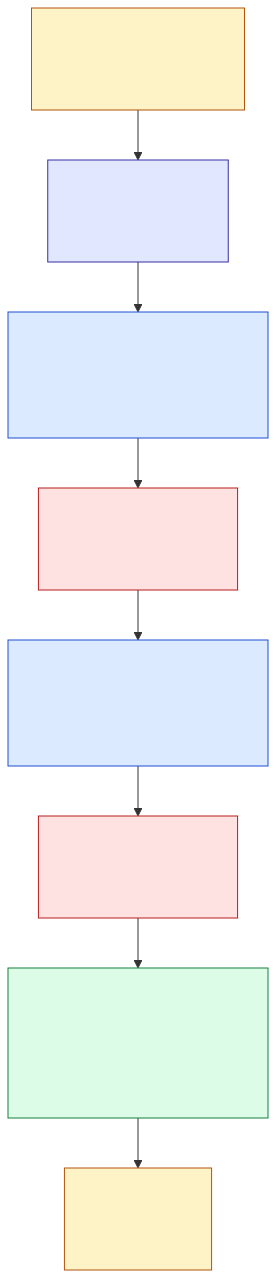

In [32]:
import base64
import urllib.request
from IPython.display import SVG, display

def render_mermaid(diagram: str) -> None:
    """Render a Mermaid diagram inline by fetching a pre-rendered SVG from mermaid.ink.

    Works in Google Colab, Jupyter, JupyterLab, and VS Code notebooks.
    Falls back to printing the source if the service is unreachable.
    """
    encoded = base64.urlsafe_b64encode(diagram.strip().encode("utf-8")).decode("ascii")
    url = f"https://mermaid.ink/svg/{encoded}"
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (notebook)"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            display(SVG(resp.read()))
    except Exception as exc:
        print(f"[mermaid.ink unavailable: {exc}] — diagram source below:\n")
        print(diagram)

MODEL_ARCHITECTURE_DIAGRAM = """
flowchart TD
    A["Input image<br/>shape: (28, 28)<br/>dtype: float32 in [0, 1]"]:::io
    B["Flatten<br/>(28, 28) -> (784,)<br/>0 params"]:::reshape
    C["Dense - hidden_1<br/>units=256, activation=ReLU<br/>784*256 + 256 = 200,960 params"]:::dense
    D["Dropout<br/>rate=0.2 (train only)<br/>0 params"]:::reg
    E["Dense - hidden_2<br/>units=128, activation=ReLU<br/>256*128 + 128 = 32,896 params"]:::dense
    F["Dropout<br/>rate=0.2 (train only)<br/>0 params"]:::reg
    G["Dense - output<br/>units=10, activation=Softmax<br/>128*10 + 10 = 1,290 params"]:::output
    H["Probabilities<br/>shape: (10,)<br/>sum p_i = 1"]:::io

    A --> B --> C --> D --> E --> F --> G --> H

    classDef io       fill:#fef3c7,stroke:#b45309,stroke-width:1px,color:#111
    classDef reshape  fill:#e0e7ff,stroke:#3730a3,stroke-width:1px,color:#111
    classDef dense    fill:#dbeafe,stroke:#1d4ed8,stroke-width:1px,color:#111
    classDef reg      fill:#fee2e2,stroke:#b91c1c,stroke-width:1px,color:#111
    classDef output   fill:#dcfce7,stroke:#15803d,stroke-width:1px,color:#111
"""

render_mermaid(MODEL_ARCHITECTURE_DIAGRAM)

In [33]:
def create_model(cfg: dict) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(cfg["hidden_units_1"], activation="relu"),
        tf.keras.layers.Dropout(cfg["dropout_rate"]),
        tf.keras.layers.Dense(cfg["hidden_units_2"], activation="relu"),
        tf.keras.layers.Dropout(cfg["dropout_rate"]),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = create_model(CONFIG)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

Trains for `CONFIG["epochs"]` and keeps `validation_split` of the training data aside for validation.

In [34]:
history = model.fit(
    x_train_norm, y_train,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    validation_split=CONFIG["validation_split"],
    shuffle=True,
    verbose=2,
)
hist_df = pd.DataFrame(history.history)
hist_df.index.name = "epoch"
hist_df.tail()

Epoch 1/50
12/12 - 4s - 295ms/step - accuracy: 0.6751 - loss: 1.0687 - val_accuracy: 0.8957 - val_loss: 0.3540
Epoch 2/50
12/12 - 0s - 20ms/step - accuracy: 0.8832 - loss: 0.3897 - val_accuracy: 0.9302 - val_loss: 0.2413
Epoch 3/50
12/12 - 0s - 18ms/step - accuracy: 0.9215 - loss: 0.2696 - val_accuracy: 0.9447 - val_loss: 0.1879
Epoch 4/50
12/12 - 0s - 18ms/step - accuracy: 0.9354 - loss: 0.2126 - val_accuracy: 0.9539 - val_loss: 0.1562
Epoch 5/50
12/12 - 0s - 18ms/step - accuracy: 0.9485 - loss: 0.1761 - val_accuracy: 0.9586 - val_loss: 0.1369
Epoch 6/50
12/12 - 0s - 17ms/step - accuracy: 0.9553 - loss: 0.1512 - val_accuracy: 0.9623 - val_loss: 0.1238
Epoch 7/50
12/12 - 0s - 18ms/step - accuracy: 0.9614 - loss: 0.1308 - val_accuracy: 0.9650 - val_loss: 0.1135
Epoch 8/50
12/12 - 0s - 24ms/step - accuracy: 0.9653 - loss: 0.1167 - val_accuracy: 0.9660 - val_loss: 0.1063
Epoch 9/50
12/12 - 0s - 25ms/step - accuracy: 0.9691 - loss: 0.1038 - val_accuracy: 0.9690 - val_loss: 0.0988
Epoch 10/

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
45,0.9955,0.0150,0.9777,0.0904
46,0.9950,0.0155,0.9793,0.0875
47,0.9957,0.0136,0.9800,0.0858
48,0.9958,0.0124,0.9797,0.0878
49,0.9965,0.0108,0.9797,0.0897


## 9. Interactive Training Curves (Plotly)

Two synced subplots — loss on the left, accuracy on the right. Hover for exact values, double-click a legend entry to isolate a trace.

In [35]:
def plot_history(hist: pd.DataFrame) -> go.Figure:
    epochs_axis = hist.index + 1
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=("Loss", "Accuracy"))

    fig.add_trace(go.Scatter(x=epochs_axis, y=hist["loss"],
                             mode="lines+markers", name="train loss"),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs_axis, y=hist["val_loss"],
                             mode="lines+markers", name="val loss"),
                  row=1, col=1)

    fig.add_trace(go.Scatter(x=epochs_axis, y=hist["accuracy"],
                             mode="lines+markers", name="train acc"),
                  row=1, col=2)
    fig.add_trace(go.Scatter(x=epochs_axis, y=hist["val_accuracy"],
                             mode="lines+markers", name="val acc"),
                  row=1, col=2)

    fig.update_xaxes(title_text="epoch", row=1, col=1)
    fig.update_xaxes(title_text="epoch", row=1, col=2)
    fig.update_yaxes(title_text="loss",     row=1, col=1)
    fig.update_yaxes(title_text="accuracy", row=1, col=2)
    fig.update_layout(
        title=f"Training history ({MODE} mode)",
        height=420, width=950,
        hovermode="x unified",
        legend=dict(orientation="h", y=-0.2),
    )
    return fig

plot_history(hist_df).show()

## 10. Evaluate on the Test Set

In [36]:
test_loss, test_acc = model.evaluate(x_test_norm, y_test, batch_size=CONFIG["batch_size"], verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss    : 0.0733
Test accuracy: 0.9823


## 11. Confusion Matrix (Plotly Heatmap)

Interactive confusion matrix — hover any cell to see the count and per-cell color encodes the magnitude.

In [37]:
y_pred_proba = model.predict(x_test_norm, batch_size=CONFIG["batch_size"], verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

cm = confusion_matrix(y_test, y_pred)
labels = [str(i) for i in range(10)]

fig_cm = px.imshow(
    cm,
    x=labels, y=labels,
    color_continuous_scale="Blues",
    text_auto=True,
    aspect="equal",
    labels=dict(x="Predicted", y="True", color="Count"),
    title="Confusion matrix — test set",
)
fig_cm.update_layout(width=620, height=560)
fig_cm.show()

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9838    0.9918    0.9878       980
           1     0.9895    0.9930    0.9912      1135
           2     0.9768    0.9806    0.9787      1032
           3     0.9756    0.9901    0.9828      1010
           4     0.9719    0.9878    0.9798       982
           5     0.9864    0.9776    0.9820       892
           6     0.9844    0.9854    0.9849       958
           7     0.9862    0.9728    0.9794      1028
           8     0.9805    0.9815    0.9810       974
           9     0.9878    0.9613    0.9744      1009

    accuracy                         0.9823     10000
   macro avg     0.9823    0.9822    0.9822     10000
weighted avg     0.9823    0.9823    0.9823     10000



## 11b. Per-class precision, recall, and F1

The confusion matrix shows raw counts; this view normalizes those into the three standard per-class metrics so it's easy to spot **which digits the model is good or bad at**. A short bar dipping below the others is the digit you'd want to investigate first.

In [38]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=list(range(10)), zero_division=0
)

metrics_df = pd.DataFrame({
    "digit":     [str(i) for i in range(10)],
    "precision": prec,
    "recall":    rec,
    "f1":        f1,
    "support":   support,
})

fig_metrics = go.Figure()
for metric in ("precision", "recall", "f1"):
    fig_metrics.add_trace(go.Bar(
        x=metrics_df["digit"], y=metrics_df[metric], name=metric,
        text=[f"{v:.3f}" for v in metrics_df[metric]],
        textposition="outside",
    ))
fig_metrics.update_layout(
    title="Per-class precision / recall / F1 — test set",
    xaxis_title="digit",
    yaxis_title="score",
    yaxis_range=[0, 1.08],
    barmode="group",
    height=440, width=950,
    legend=dict(orientation="h", y=-0.18),
)
fig_metrics.show()

metrics_df.style.format({"precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}"})

,digit,precision,recall,f1,support
0,0,0.9838,0.9918,0.9878,980
1,1,0.9895,0.9930,0.9912,1135
2,2,0.9768,0.9806,0.9787,1032
3,3,0.9756,0.9901,0.9828,1010
4,4,0.9719,0.9878,0.9798,982
5,5,0.9864,0.9776,0.9820,892
6,6,0.9844,0.9854,0.9849,958
7,7,0.9862,0.9728,0.9794,1028
8,8,0.9805,0.9815,0.9810,974
9,9,0.9878,0.9613,0.9744,1009


## 11c. Prediction-confidence distribution

For every test example we take the **top-class softmax probability** (the model's confidence) and split those values into two histograms: predictions that were **correct** vs **wrong**. A healthy classifier shows:

- Correct predictions clustered at very high confidence (right side).
- Wrong predictions concentrated at lower confidence (left side).

If wrong predictions are also extremely confident, the model is over-confident and probability-based thresholds (e.g. "only auto-approve if confidence ≥ 0.95") won't help much.

In [39]:
top_proba = y_pred_proba.max(axis=1)
is_correct = (y_pred == y_test)

fig_conf = go.Figure()
fig_conf.add_trace(go.Histogram(
    x=top_proba[is_correct], name=f"correct (n={is_correct.sum()})",
    nbinsx=40, opacity=0.75, marker_color="#15803d",
))
fig_conf.add_trace(go.Histogram(
    x=top_proba[~is_correct], name=f"wrong (n={(~is_correct).sum()})",
    nbinsx=40, opacity=0.75, marker_color="#b91c1c",
))
fig_conf.update_layout(
    title="Top-class softmax probability — correct vs wrong predictions",
    xaxis_title="model confidence",
    yaxis_title="count (log scale)",
    yaxis_type="log",
    barmode="overlay",
    height=420, width=900,
    legend=dict(orientation="h", y=-0.2),
)
fig_conf.show()

print(f"Mean confidence when correct: {top_proba[is_correct].mean():.4f}")
print(f"Mean confidence when wrong  : {top_proba[~is_correct].mean():.4f}")

Mean confidence when correct: 0.9951
Mean confidence when wrong  : 0.8055


## 11d. Gallery of misclassified examples

The model is right roughly 98% of the time — so to see what's hard, we look at the **wrong** predictions. The grid below shows up to 15 misclassifications, each titled with the **true** label, the **predicted** label, and the model's confidence in that wrong guess. Many of these are genuinely ambiguous handwriting; the rest reveal where the model could still improve.

In [40]:
wrong_idx = np.where(~is_correct)[0]
print(f"Total misclassifications: {len(wrong_idx)}")

n_show = min(15, len(wrong_idx))
if n_show == 0:
    print("No misclassifications to display — nice model!")
else:
    sample = rng.choice(wrong_idx, size=n_show, replace=False)
    rows = (n_show + 4) // 5
    titles = [
        f"true {y_test[i]} | pred {y_pred[i]} ({y_pred_proba[i][y_pred[i]]:.0%})"
        for i in sample
    ]
    fig_wrong = make_subplots(rows=rows, cols=5, subplot_titles=titles,
                              vertical_spacing=0.12)
    for plot_idx, img_idx in enumerate(sample):
        r, c = plot_idx // 5 + 1, plot_idx % 5 + 1
        fig_wrong.add_trace(
            go.Heatmap(z=x_test[img_idx][::-1], colorscale="gray_r", showscale=False),
            row=r, col=c,
        )
    fig_wrong.update_xaxes(visible=False)
    fig_wrong.update_yaxes(visible=False, scaleanchor="x")
    fig_wrong.update_layout(
        title="Random misclassified test examples",
        height=220 * rows + 80, width=950,
        margin=dict(l=20, r=20, t=80, b=20),
    )
    fig_wrong.show()

Total misclassifications: 177


## 12. Save Artifacts with `pickle`

We save **two** files into `./artifacts/`:

- `mnist_model.keras` — Keras-native model file (recommended way to serialize a `tf.keras` model).
- `mnist_artifacts.pkl` — a pickled dict containing the **preprocessing function**, **class labels**, **config**, **training history**, and the **path to the model file**. The prediction notebook only needs this pickle to fully reconstruct the inference pipeline.

> Why not pickle the Keras model directly? `tf.keras` models contain non-picklable internals; the official path is `.keras`/`.h5` for the weights+graph and pickle for everything else.

In [41]:
model_path = ARTIFACT_DIR / "mnist_model.keras"
pickle_path = ARTIFACT_DIR / "mnist_artifacts.pkl"

model.save(model_path)

artifacts = {
    "model_path": str(model_path.name),
    "class_labels": list(range(10)),
    "input_shape": (28, 28),
    "preprocess": normalize,
    "config": CONFIG,
    "mode": MODE,
    "history": hist_df.to_dict(),
    "test_metrics": {"loss": float(test_loss), "accuracy": float(test_acc)},
    "tensorflow_version": tf.__version__,
}

with open(pickle_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved model     -> {model_path}")
print(f"Saved artifacts -> {pickle_path}")
print(f"Artifact keys   : {list(artifacts.keys())}")

Saved model     -> artifacts/mnist_model.keras
Saved artifacts -> artifacts/mnist_artifacts.pkl
Artifact keys   : ['model_path', 'class_labels', 'input_shape', 'preprocess', 'config', 'mode', 'history', 'test_metrics', 'tensorflow_version']


## 13. Next Step

Open `02_MNIST_Prediction.ipynb` to load the saved artifacts and run inference on new images.